# 🔵 Algorithmes de Clustering — Classification Non Supervisée
### Python · Scikit-learn · Datasets réels (Iris, Wine, Digits)
> **Auteur :** A. LArhlimi | **Date :** Mars 2026

## ⚙️ Installation des dépendances

In [ ]:
!pip install scikit-learn scipy numpy matplotlib pandas hdbscan --quiet
print("✅ Dépendances installées")

✅ Dépendances installées


## 📦 Imports globaux

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

print("✅ Imports OK")

✅ Imports OK


## 📂 Chargement et préparation des Datasets

In [ ]:
iris    = datasets.load_iris()
wine    = datasets.load_wine()
digits  = datasets.load_digits()

# Normalisation (obligatoire pour la plupart des algorithmes)
sc = StandardScaler()
X_iris  = sc.fit_transform(iris.data)
X_wine  = sc.fit_transform(wine.data)
X_dig   = sc.fit_transform(digits.data)

# Réduction PCA 2D pour visualisation
pca2 = PCA(n_components=2, random_state=42)
X_iris_2d  = pca2.fit_transform(X_iris)
X_wine_2d  = pca2.fit_transform(X_wine)

def plot_clusters(X_2d, labels, title, true_labels=None):
    fig, axes = plt.subplots(1, 2 if true_labels is not None else 1,
                              figsize=(14 if true_labels is not None else 6, 5))
    ax = axes[0] if true_labels is not None else axes
    unique = np.unique(labels)
    cmap   = cm.get_cmap('tab10', len(unique))
    for i, lbl in enumerate(unique):
        mask = labels == lbl
        name = f"Cluster {lbl}" if lbl >= 0 else "Bruit"
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=20,
                   color='black' if lbl == -1 else cmap(i), label=name, alpha=0.7)
    ax.set_title(title)
    ax.legend(fontsize=7)
    if true_labels is not None:
        ax2 = axes[1]
        for i, name in enumerate(np.unique(true_labels)):
            mask = true_labels == i
            ax2.scatter(X_2d[mask, 0], X_2d[mask, 1], s=20, color=cmap(i),
                        label=str(name), alpha=0.7)
        ax2.set_title("Labels réels")
        ax2.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

print("✅ Datasets prêts :", iris.data.shape, wine.data.shape, digits.data.shape)

✅ Datasets prêts : (150, 4) (178, 13) (1797, 64)


## 📏 Métriques d'évaluation

### Score de Silhouette
`s(i) = (b(i) - a(i)) / max(a(i), b(i))`
- **a(i)** : distance moyenne au sein du même cluster (cohésion)
- **b(i)** : distance moyenne vers le cluster voisin (séparation)
- **s(i) ∈ [-1, 1]** : proche de 1 = bien classé · 0 = frontière · négatif = mal classé

### Inertie (WCSS)
Somme des distances au carré entre chaque point et le centroïde. Utilisée pour la méthode Elbow.

In [ ]:
def eval_clustering(X, labels, name=""):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = list(labels).count(-1)
    if n_clusters < 2:
        print(f"{name} → Clusters={n_clusters}  (impossible de calculer silhouette)")
        return None
    # Exclure les points bruit pour la silhouette
    mask = labels != -1
    sil  = silhouette_score(X[mask], labels[mask]) if mask.sum() > 1 else None
    print(f"{name:35s} | Clusters={n_clusters:2d} | Bruit={n_noise:3d} | Silhouette={sil:.4f}" if sil else f"{name} | Clusters={n_clusters}")
    return sil

print("Fonction eval_clustering définie ✅")

Fonction eval_clustering définie ✅


---
# 1️⃣ K-Means
**Principe :** Partitionne en K clusters en minimisant l'inertie. Algorithme de Lloyd avec initialisation K-Means++.

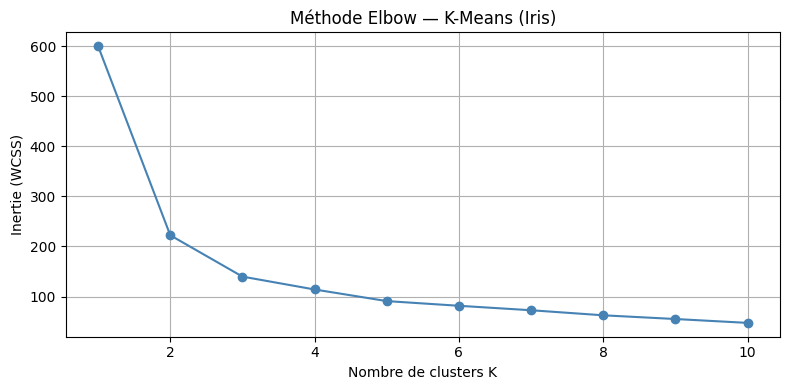

K-Means K=3 (Iris)                  | Clusters= 3 | Bruit=  0 | Silhouette=0.4599


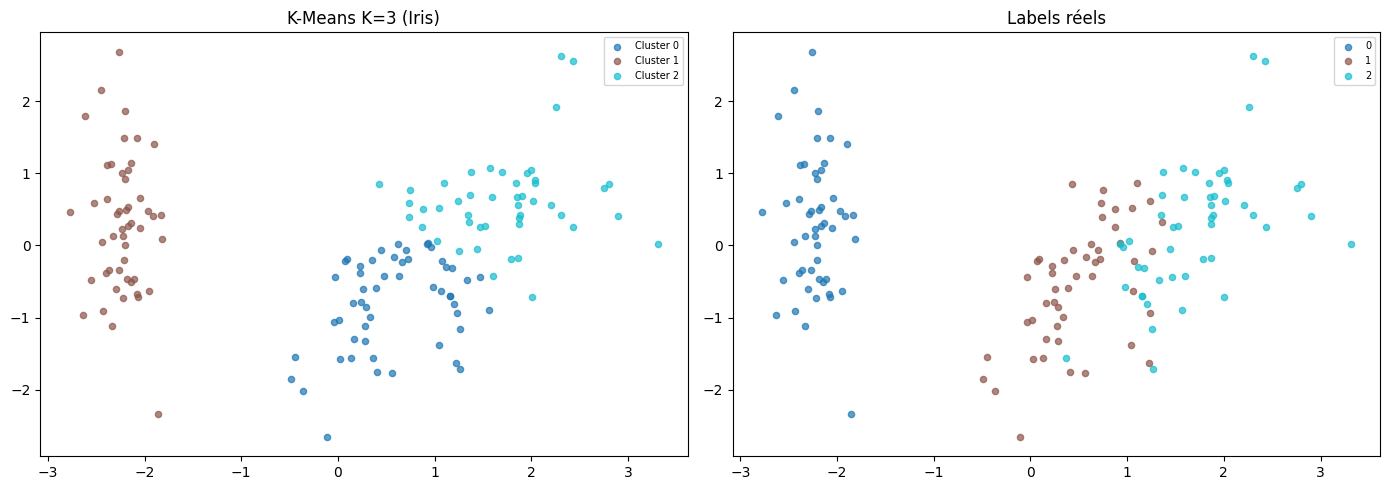

In [ ]:
from sklearn.cluster import KMeans

# ── Méthode Elbow ─────────────────────────────────────────────────────────
inertias = []
K_range  = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_iris)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker='o', color='steelblue')
plt.xlabel("Nombre de clusters K")
plt.ylabel("Inertie (WCSS)")
plt.title("Méthode Elbow — K-Means (Iris)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Modèle final K=3 ──────────────────────────────────────────────────────
km3 = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
labels_km = km3.fit_predict(X_iris)

eval_clustering(X_iris, labels_km, "K-Means K=3 (Iris)")
plot_clusters(X_iris_2d, labels_km, "K-Means K=3 (Iris)", iris.target)

---
## 2️⃣ K-Medoids (PAM)
**Principe :** Variante de K-Means où les centres sont des **points réels** du dataset. Robuste aux outliers.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 11.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

⚠️  scikit-learn-extra non disponible — simulation via K-Means
Simulation K-Medoids — médoïdes approx. : [126   4  45]
K-Medoids simulé K=3 (Iris)         | Clusters= 3 | Bruit=  0 | Silhouette=0.4799


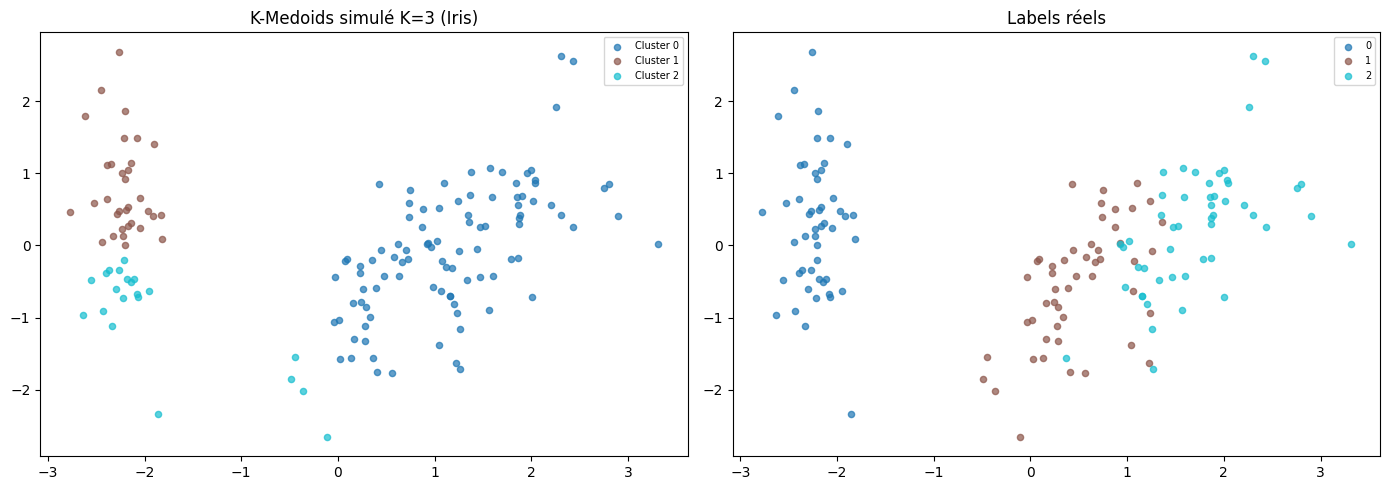

In [ ]:
try:
    from sklearn_extra.cluster import KMedoids
    USE_KMEDOIDS = True
except ImportError:
    !pip install scikit-learn-extra --quiet
    try:
        from sklearn_extra.cluster import KMedoids
        USE_KMEDOIDS = True
    except:
        USE_KMEDOIDS = False
        print("⚠️  scikit-learn-extra non disponible — simulation via K-Means")

if USE_KMEDOIDS:
    kmed = KMedoids(n_clusters=3, metric='euclidean', random_state=42)
    labels_kmed = kmed.fit_predict(X_iris)
    eval_clustering(X_iris, labels_kmed, "K-Medoids K=3 (Iris)")
    plot_clusters(X_iris_2d, labels_kmed, "K-Medoids K=3 (Iris)", iris.target)
    print(f"Médoïdes (indices) : {kmed.medoid_indices_}")
else:
    # Simulation : K-Means + recherche du point le plus proche de chaque centroïde
    from sklearn.cluster import KMeans
    from sklearn.metrics import pairwise_distances_argmin
    km_sim = KMeans(n_clusters=3, random_state=42).fit(X_iris)
    medoids_idx = pairwise_distances_argmin(km_sim.cluster_centers_, X_iris)
    print(f"Simulation K-Medoids — médoïdes approx. : {medoids_idx}")
    labels_kmed = km_sim.labels_
    eval_clustering(X_iris, labels_kmed, "K-Medoids simulé K=3 (Iris)")
    plot_clusters(X_iris_2d, labels_kmed, "K-Medoids simulé K=3 (Iris)", iris.target)

---
## 3️⃣ K-Medians
**Principe :** Utilise la **médiane** (L1) au lieu de la moyenne (L2) → plus robuste aux outliers.

K-Medians K=3 (Iris)                | Clusters= 3 | Bruit=  0 | Silhouette=0.4489


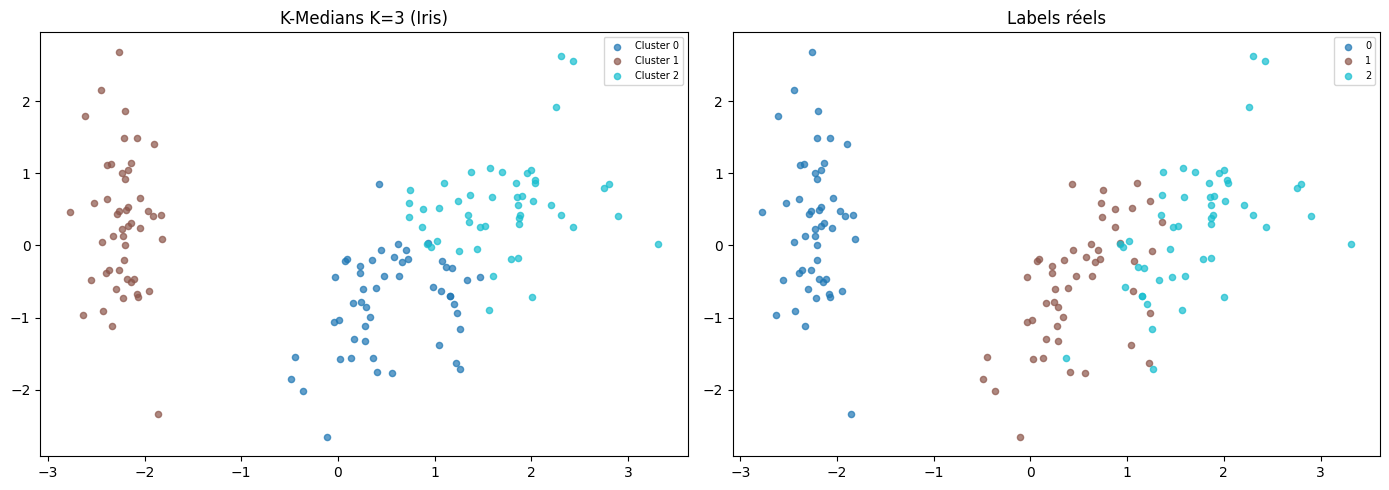

In [ ]:
# Implémentation manuelle de K-Medians (non inclus dans sklearn)
def k_medians(X, k, max_iter=100, random_state=42):
    rng = np.random.default_rng(random_state)
    idx = rng.choice(len(X), k, replace=False)
    centers = X[idx].copy()
    labels  = np.zeros(len(X), dtype=int)
    for _ in range(max_iter):
        # Assignation : distance Manhattan
        dists  = np.array([np.sum(np.abs(X - c), axis=1) for c in centers])
        new_lb = np.argmin(dists, axis=0)
        if np.all(new_lb == labels):
            break
        labels = new_lb
        # Mise à jour : médiane
        for j in range(k):
            mask = labels == j
            if mask.sum() > 0:
                centers[j] = np.median(X[mask], axis=0)
    return labels, centers

labels_km_med, centers_km_med = k_medians(X_iris, k=3)
eval_clustering(X_iris, labels_km_med, "K-Medians K=3 (Iris)")
plot_clusters(X_iris_2d, labels_km_med, "K-Medians K=3 (Iris)", iris.target)

---
## 4️⃣ DBSCAN
**Principe :** Clustering par **densité locale**. Détecte des formes arbitraires et marque les outliers comme bruit.

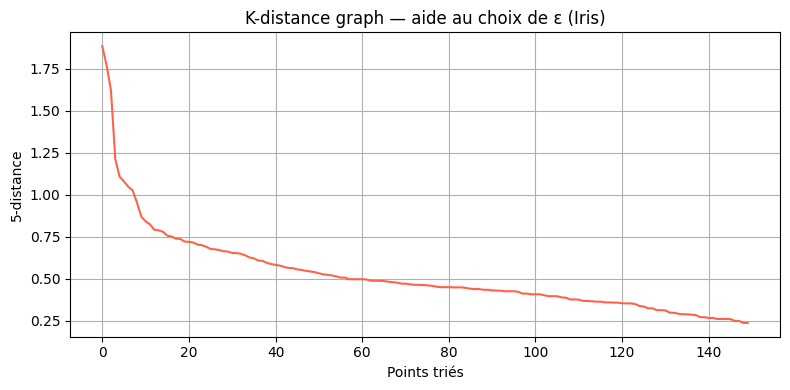

DBSCAN eps=0.5 min=5 (Iris)         | Clusters= 2 | Bruit= 34 | Silhouette=0.6559


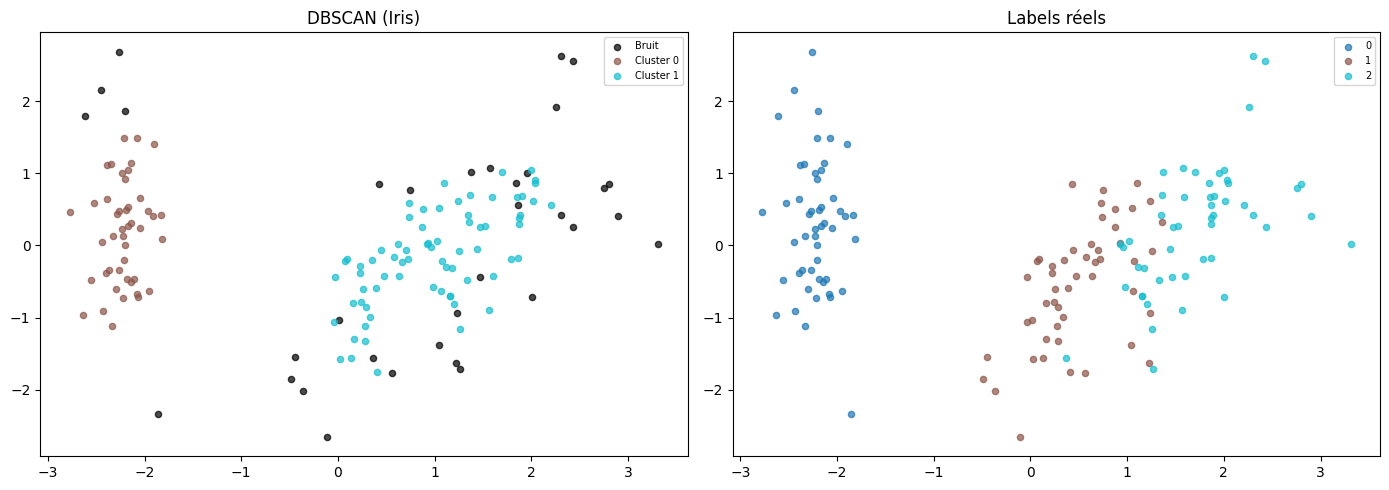


Exploration eps / min_samples :
   eps  min | Clusters  Bruit Silhouette
----------------------------------------
   0.3    3 |       10     84     0.3974
   0.3    5 |        3    120     0.6302
   0.5    3 |        7     17     0.2591
   0.5    5 |        2     34     0.6559
   0.5   10 |        3     89     0.7101
   0.8    3 |        2      4     0.5979
   0.8    5 |        2      4     0.5979
   0.8   10 |        2      8     0.6083


In [ ]:
from sklearn.cluster import DBSCAN

# ── Choix de epsilon via k-distance graph ─────────────────────────────────
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=5).fit(X_iris)
distances, _ = nbrs.kneighbors(X_iris)
k_dist = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_dist, color='tomato')
plt.xlabel("Points triés")
plt.ylabel("5-distance")
plt.title("K-distance graph — aide au choix de ε (Iris)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Modèle DBSCAN ─────────────────────────────────────────────────────────
db = DBSCAN(eps=0.5, min_samples=5, metric='euclidean')
labels_db = db.fit_predict(X_iris)
eval_clustering(X_iris, labels_db, "DBSCAN eps=0.5 min=5 (Iris)")
plot_clusters(X_iris_2d, labels_db, "DBSCAN (Iris)", iris.target)

# ── Exploration des paramètres ────────────────────────────────────────────
print("\nExploration eps / min_samples :")
print(f"{'eps':>6} {'min':>4} | {'Clusters':>8} {'Bruit':>6} {'Silhouette':>10}")
print("-" * 40)
for eps in [0.3, 0.5, 0.8]:
    for ms in [3, 5, 10]:
        lbl = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_iris)
        nc  = len(set(lbl)) - (1 if -1 in lbl else 0)
        nb  = list(lbl).count(-1)
        if nc >= 2:
            mask = lbl != -1
            sil  = silhouette_score(X_iris[mask], lbl[mask])
            print(f"{eps:>6.1f} {ms:>4d} | {nc:>8d} {nb:>6d} {sil:>10.4f}")

---
## 5️⃣ HDBSCAN
**Principe :** Extension hiérarchique de DBSCAN. Un seul paramètre `min_cluster_size`. Gère les densités variables.

HDBSCAN min_size=10 (Iris)          | Clusters= 2 | Bruit=  2 | Silhouette=0.5853


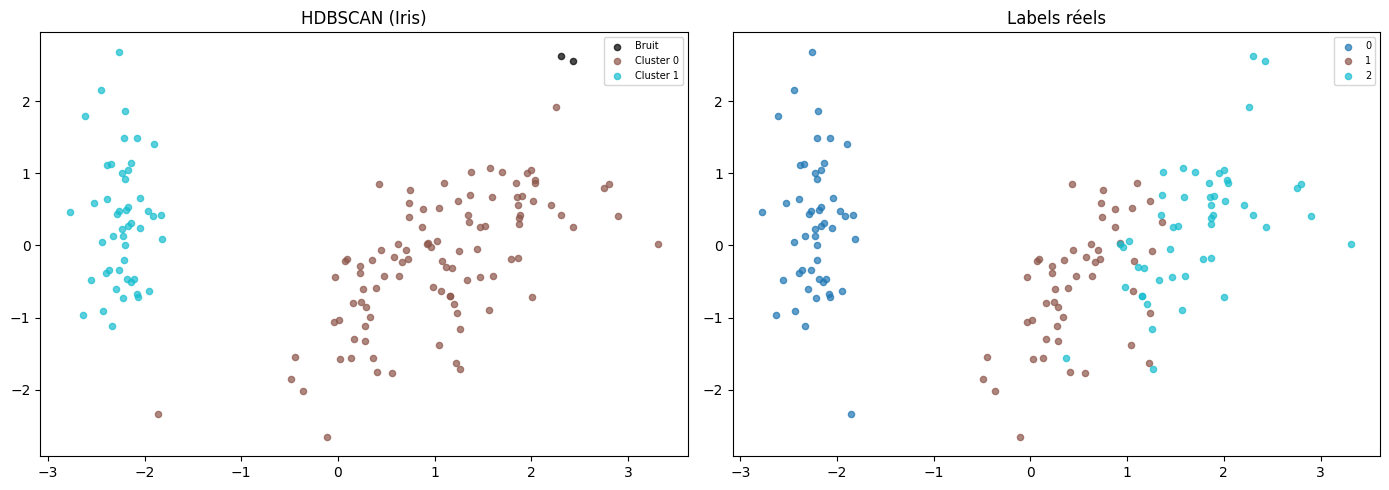


Probabilités d'appartenance (5 premiers points):
[[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]


In [ ]:
try:
    import hdbscan
    hdb = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5, prediction_data=True)
    labels_hdb = hdb.fit_predict(X_iris)
    eval_clustering(X_iris, labels_hdb, "HDBSCAN min_size=10 (Iris)")
    plot_clusters(X_iris_2d, labels_hdb, "HDBSCAN (Iris)", iris.target)

    # Probabilités d'appartenance
    proba = hdbscan.membership_vector(hdb, X_iris[:5])
    print("\nProbabilités d'appartenance (5 premiers points):")
    print(np.round(proba, 3))

except ImportError:
    print("⚠️  hdbscan non installé — utilisation de sklearn HDBSCAN")
    from sklearn.cluster import HDBSCAN
    hdb = HDBSCAN(min_cluster_size=10, min_samples=5)
    labels_hdb = hdb.fit_predict(X_iris)
    eval_clustering(X_iris, labels_hdb, "HDBSCAN min_size=10 (Iris)")
    plot_clusters(X_iris_2d, labels_hdb, "HDBSCAN (Iris)", iris.target)

---
## 6️⃣ OPTICS
**Principe :** Génère un ordonnancement des points (reachability plot) révélant la structure à plusieurs densités.

OPTICS (Iris)                       | Clusters= 3 | Bruit= 67 | Silhouette=0.6255


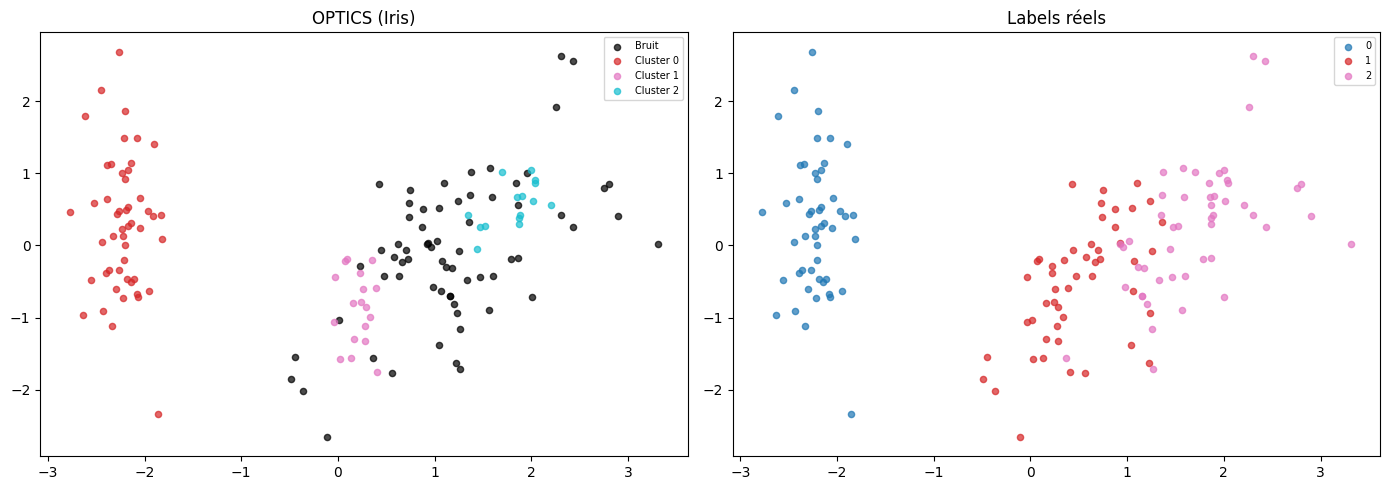

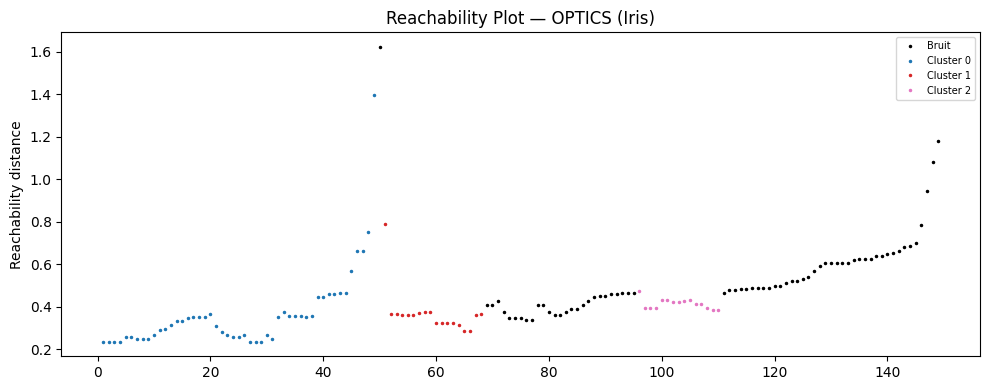

In [ ]:
from sklearn.cluster import OPTICS

opt = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.1)
opt.fit(X_iris)
labels_opt = opt.labels_

eval_clustering(X_iris, labels_opt, "OPTICS (Iris)")
plot_clusters(X_iris_2d, labels_opt, "OPTICS (Iris)", iris.target)

# Reachability plot
plt.figure(figsize=(10, 4))
space      = np.arange(len(X_iris))
reachability = opt.reachability_[opt.ordering_]
lbl_ord    = opt.labels_[opt.ordering_]
cmap       = cm.get_cmap('tab10', max(labels_opt)+2)
for klass in np.unique(lbl_ord):
    mask = lbl_ord == klass
    color = 'black' if klass == -1 else cmap(klass)
    plt.plot(space[mask], reachability[mask], '.', color=color,
             label=f"Cluster {klass}" if klass>=0 else "Bruit", markersize=3)
plt.ylabel("Reachability distance")
plt.title("Reachability Plot — OPTICS (Iris)")
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

---
## 7️⃣ Clustering Hiérarchique Agglomératif (HAC)
**Principe :** Fusionne progressivement les clusters les plus similaires. Résultat = dendrogramme.

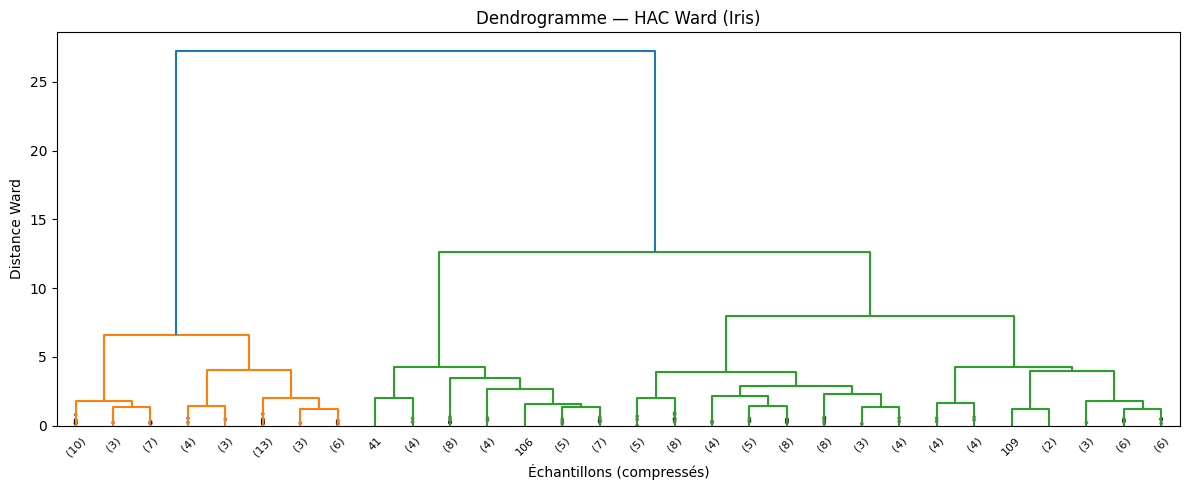

Comparaison des linkages :
Linkage      | Silhouette
---------------------------
ward         |     0.4467
complete     |     0.4496
average      |     0.4803
single       |     0.5046


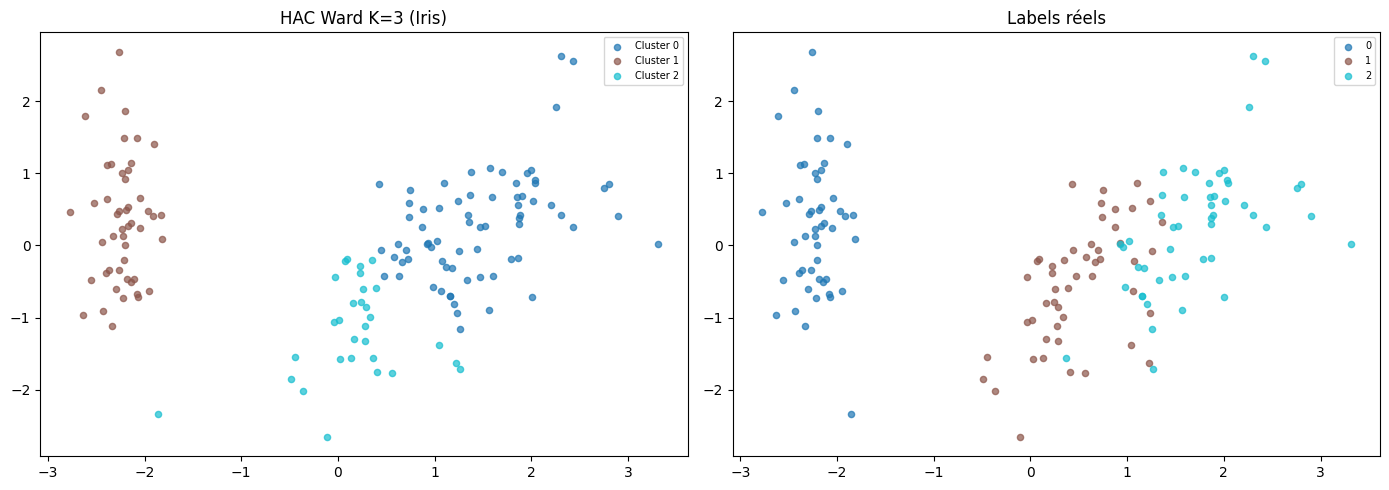

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# ── Dendrogramme ─────────────────────────────────────────────────────────
linked = linkage(X_iris, method='ward')
plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='lastp', p=30,
           leaf_rotation=45, leaf_font_size=8, show_contracted=True)
plt.title("Dendrogramme — HAC Ward (Iris)")
plt.xlabel("Échantillons (compressés)")
plt.ylabel("Distance Ward")
plt.tight_layout()
plt.show()

# ── Comparaison des méthodes de liaison ──────────────────────────────────
print("Comparaison des linkages :")
print(f"{'Linkage':12s} | {'Silhouette':>10}")
print("-" * 27)
for linkage_method in ['ward', 'complete', 'average', 'single']:
    hac = AgglomerativeClustering(n_clusters=3, linkage=linkage_method)
    lbl = hac.fit_predict(X_iris)
    sil = silhouette_score(X_iris, lbl)
    print(f"{linkage_method:12s} | {sil:>10.4f}")

# ── Meilleur modèle (Ward) ────────────────────────────────────────────────
hac_best = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hac = hac_best.fit_predict(X_iris)
plot_clusters(X_iris_2d, labels_hac, "HAC Ward K=3 (Iris)", iris.target)

---
## 8️⃣ Gaussian Mixture Models (GMM)
**Principe :** Modèle probabiliste — mélange de K gaussiennes. Algorithme EM. Soft assignment.

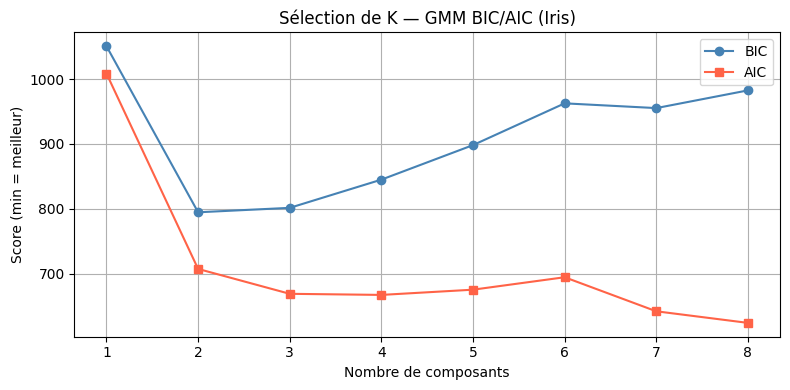

GMM K=3 full (Iris)                 | Clusters= 3 | Bruit=  0 | Silhouette=0.3742


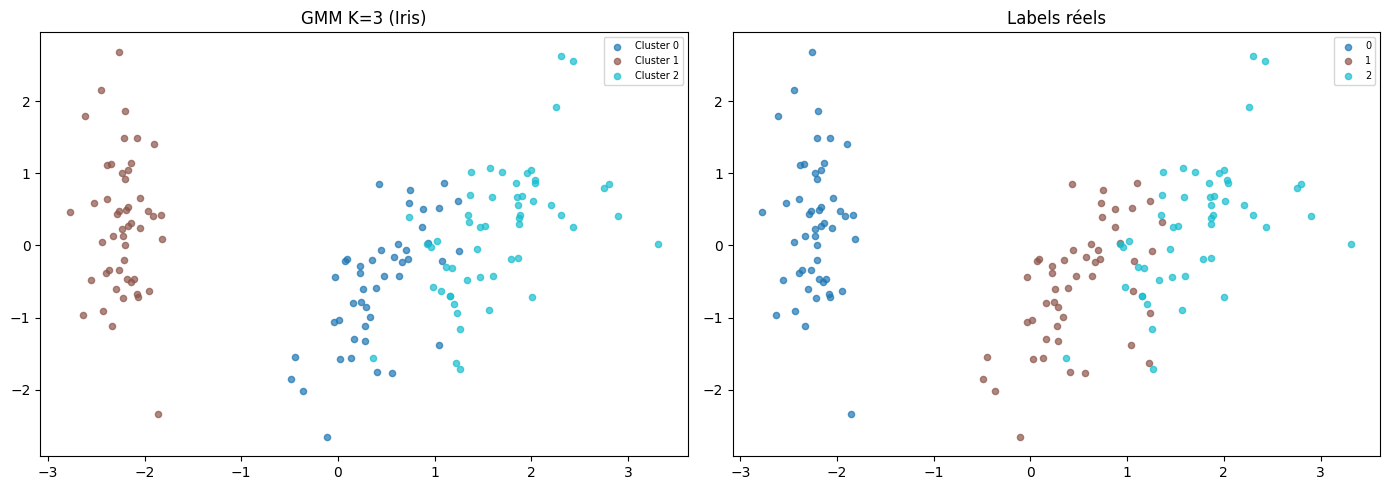


Probabilités d'appartenance (5 premiers points) :
[[0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]

Comparaison covariance_type :
  full         → Silhouette=0.3742  BIC=801.6
  tied         → Silhouette=0.3910  BIC=854.4
  diag         → Silhouette=0.4135  BIC=964.7
  spherical    → Silhouette=0.4599  BIC=1227.2


In [ ]:
from sklearn.mixture import GaussianMixture

# ── Sélection de K via BIC/AIC ────────────────────────────────────────────
n_range = range(1, 9)
bic_vals, aic_vals = [], []
for n in n_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full',
                           random_state=42, n_init=3)
    gmm.fit(X_iris)
    bic_vals.append(gmm.bic(X_iris))
    aic_vals.append(gmm.aic(X_iris))

plt.figure(figsize=(8, 4))
plt.plot(list(n_range), bic_vals, marker='o', label='BIC', color='steelblue')
plt.plot(list(n_range), aic_vals, marker='s', label='AIC', color='tomato')
plt.xlabel("Nombre de composants")
plt.ylabel("Score (min = meilleur)")
plt.title("Sélection de K — GMM BIC/AIC (Iris)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Modèle final ─────────────────────────────────────────────────────────
gmm3 = GaussianMixture(n_components=3, covariance_type='full',
                        random_state=42, n_init=5)
gmm3.fit(X_iris)
labels_gmm  = gmm3.predict(X_iris)
probas_gmm  = gmm3.predict_proba(X_iris)

eval_clustering(X_iris, labels_gmm, "GMM K=3 full (Iris)")
plot_clusters(X_iris_2d, labels_gmm, "GMM K=3 (Iris)", iris.target)

print("\nProbabilités d'appartenance (5 premiers points) :")
print(np.round(probas_gmm[:5], 3))

# Comparaison des types de covariance
print("\nComparaison covariance_type :")
for cov in ['full', 'tied', 'diag', 'spherical']:
    g = GaussianMixture(n_components=3, covariance_type=cov, random_state=42, n_init=3)
    lbl = g.fit_predict(X_iris)
    sil = silhouette_score(X_iris, lbl)
    print(f"  {cov:12s} → Silhouette={sil:.4f}  BIC={g.bic(X_iris):.1f}")

---
## 9️⃣ Spectral Clustering
**Principe :** Vecteurs propres du Laplacien du graphe de similarité → K-Means dans l'espace spectral. Clusters de formes arbitraires.

Spectral K=3 rbf (Iris)             | Clusters= 3 | Bruit=  0 | Silhouette=0.4630


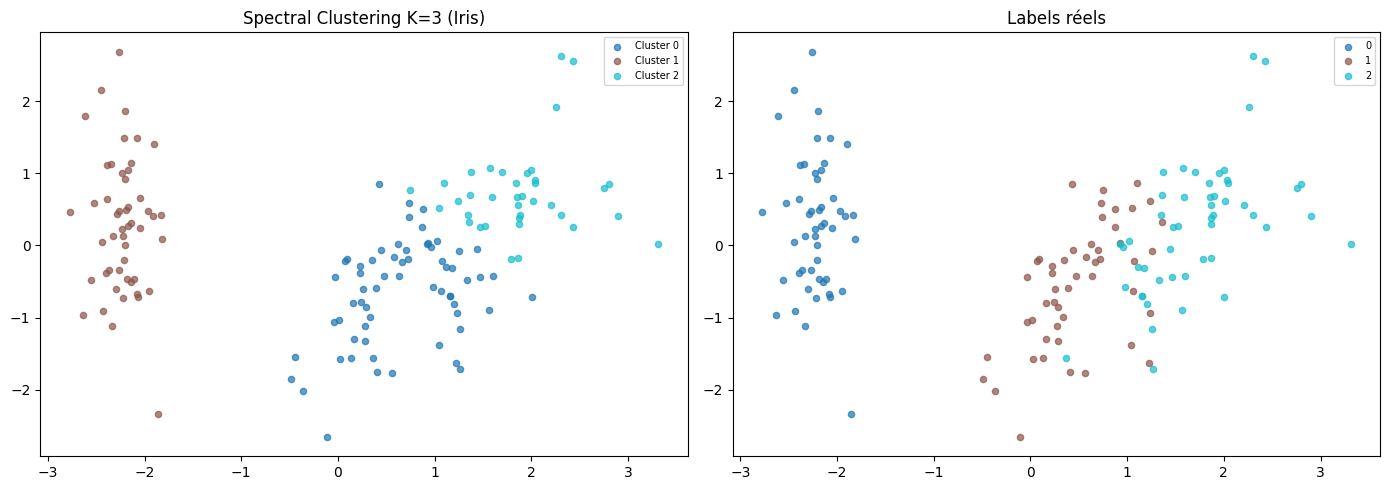

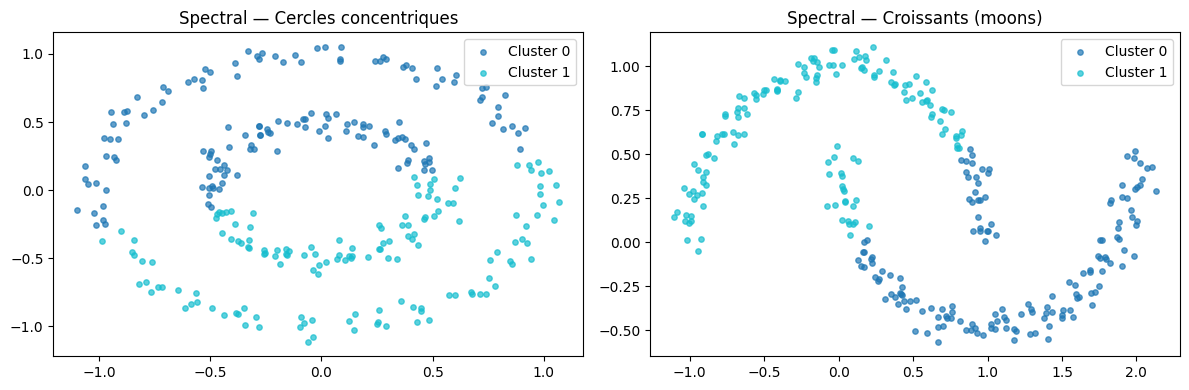

In [ ]:
from sklearn.cluster import SpectralClustering

spec = SpectralClustering(n_clusters=3, affinity='rbf', gamma=1.0,
                           assign_labels='kmeans', random_state=42, n_jobs=-1)
labels_spec = spec.fit_predict(X_iris)
eval_clustering(X_iris, labels_spec, "Spectral K=3 rbf (Iris)")
plot_clusters(X_iris_2d, labels_spec, "Spectral Clustering K=3 (Iris)", iris.target)

# Données en anneaux (forme arbitraire — cas fort de Spectral)
from sklearn.datasets import make_circles, make_moons
X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)
X_moons,   y_moons   = make_moons(n_samples=300, noise=0.05, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, X_s, y_s, title in [
        (axes[0], X_circles, y_circles, "Cercles concentriques"),
        (axes[1], X_moons,   y_moons,   "Croissants (moons)")]:
    spec_s = SpectralClustering(n_clusters=2, affinity='rbf', gamma=4,
                                 assign_labels='kmeans', random_state=42)
    lbl_s = spec_s.fit_predict(X_s)
    cmap  = cm.get_cmap('tab10', 2)
    for k in [0, 1]:
        ax.scatter(X_s[lbl_s==k, 0], X_s[lbl_s==k, 1], s=15,
                   color=cmap(k), label=f"Cluster {k}", alpha=0.7)
    ax.set_title(f"Spectral — {title}")
    ax.legend()
plt.tight_layout()
plt.show()

---
## 🔟 Affinity Propagation
**Principe :** Échange de messages entre paires de points. Détecte automatiquement K via des **exemplaires**.

In [ ]:
from sklearn.cluster import AffinityPropagation

ap = AffinityPropagation(damping=0.7, random_state=42)
labels_ap = ap.fit_predict(X_iris)
n_clusters_ap = len(ap.cluster_centers_indices_)

eval_clustering(X_iris, labels_ap, f"AffinityProp (Iris) K={n_clusters_ap}")
plot_clusters(X_iris_2d, labels_ap, f"Affinity Propagation K={n_clusters_ap} (Iris)", iris.target)

# Influence du paramètre preference
print("\nInfluence du paramètre preference :")
print(f"{'preference':>12} | {'K trouvé':>8} | {'Silhouette':>10}")
print("-" * 35)
for pref in [-200, -100, -50, -20, None]:
    ap_p = AffinityPropagation(damping=0.7, preference=pref, random_state=42)
    lbl_p = ap_p.fit_predict(X_iris)
    nc = len(ap_p.cluster_centers_indices_)
    if nc >= 2:
        sil = silhouette_score(X_iris, lbl_p)
        print(f"{str(pref):>12} | {nc:>8d} | {sil:>10.4f}")
    else:
        print(f"{str(pref):>12} | {nc:>8d} | {'N/A':>10}")

---
## 1️⃣1️⃣ Self-Organizing Maps (SOM)
**Principe :** Réseau de neurones non supervisé projetant les données HD sur une grille 2D tout en préservant la topologie.

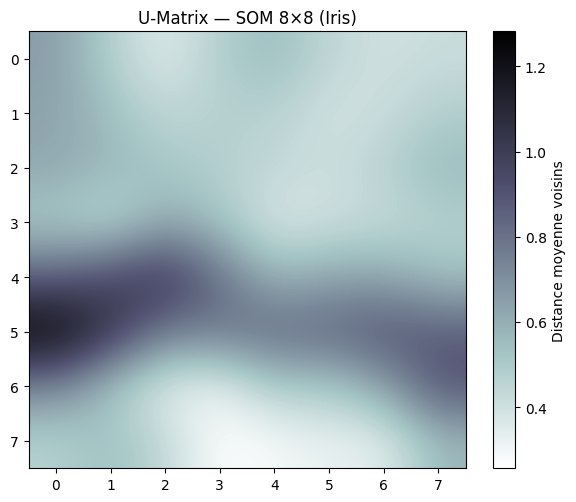

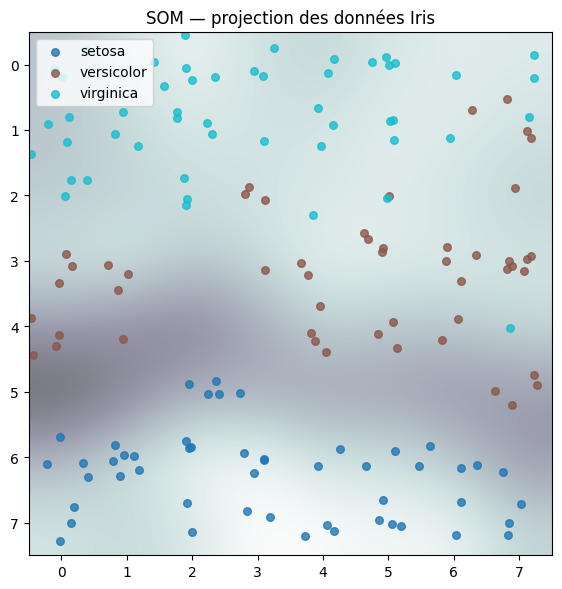

In [ ]:
# Implémentation SOM from scratch
class MiniSOM:
    def __init__(self, m, n, dim, lr=0.5, sigma=1.0, epochs=1000, seed=42):
        rng = np.random.default_rng(seed)
        self.m, self.n, self.dim = m, n, dim
        self.lr0, self.sigma0    = lr, sigma
        self.epochs              = epochs
        self.weights = rng.random((m * n, dim))
        self.grid    = np.array([[i, j] for i in range(m) for j in range(n)], dtype=float)

    def _bmu(self, x):
        dists = np.sum((self.weights - x) ** 2, axis=1)
        return np.argmin(dists)

    def fit(self, X):
        for t in range(self.epochs):
            lr    = self.lr0 * np.exp(-t / self.epochs)
            sigma = self.sigma0 * np.exp(-t / self.epochs)
            idx   = np.random.randint(len(X))
            bmu   = self._bmu(X[idx])
            d2    = np.sum((self.grid - self.grid[bmu]) ** 2, axis=1)
            h     = np.exp(-d2 / (2 * sigma ** 2))
            self.weights += lr * h[:, None] * (X[idx] - self.weights)

    def predict(self, X):
        return np.array([self._bmu(x) for x in X])

    def umatrix(self):
        m, n = self.m, self.n
        u = np.zeros((m, n))
        for i in range(m):
            for j in range(n):
                idx  = i * n + j
                nbrs = []
                for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
                    ni, nj = i+di, j+dj
                    if 0 <= ni < m and 0 <= nj < n:
                        nbrs.append(np.linalg.norm(self.weights[idx] - self.weights[ni*n+nj]))
                u[i, j] = np.mean(nbrs) if nbrs else 0
        return u

# Entraînement
som = MiniSOM(m=8, n=8, dim=X_iris.shape[1], lr=0.5, sigma=2.0, epochs=3000)
som.fit(X_iris)
bmu_labels = som.predict(X_iris)

# U-Matrix
u_mat = som.umatrix()
plt.figure(figsize=(6, 5))
plt.imshow(u_mat, cmap='bone_r', interpolation='bicubic')
plt.colorbar(label="Distance moyenne voisins")
plt.title("U-Matrix — SOM 8×8 (Iris)")
plt.tight_layout()
plt.show()

# Projection SOM 2D colorée par labels réels
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(u_mat, cmap='bone_r', interpolation='bicubic', alpha=0.6)
cmap = cm.get_cmap('tab10', 3)
for k in range(3):
    mask = iris.target == k
    bmu_k = som.predict(X_iris[mask])
    rows  = bmu_k // som.n
    cols  = bmu_k % som.n
    ax.scatter(cols + np.random.randn(mask.sum())*0.2,
               rows + np.random.randn(mask.sum())*0.2,
               color=cmap(k), s=30, label=iris.target_names[k], alpha=0.8)
ax.legend()
ax.set_title("SOM — projection des données Iris")
plt.tight_layout()
plt.show()

---
## 1️⃣2️⃣ UMAP + K-Means
**Principe :** Réduction dimensionnelle non-linéaire (UMAP) suivie d'un K-Means. Efficace sur les données HD.

UMAP + K-Means K=10 (Digits)        | Clusters=10 | Bruit=  0 | Silhouette=0.6987


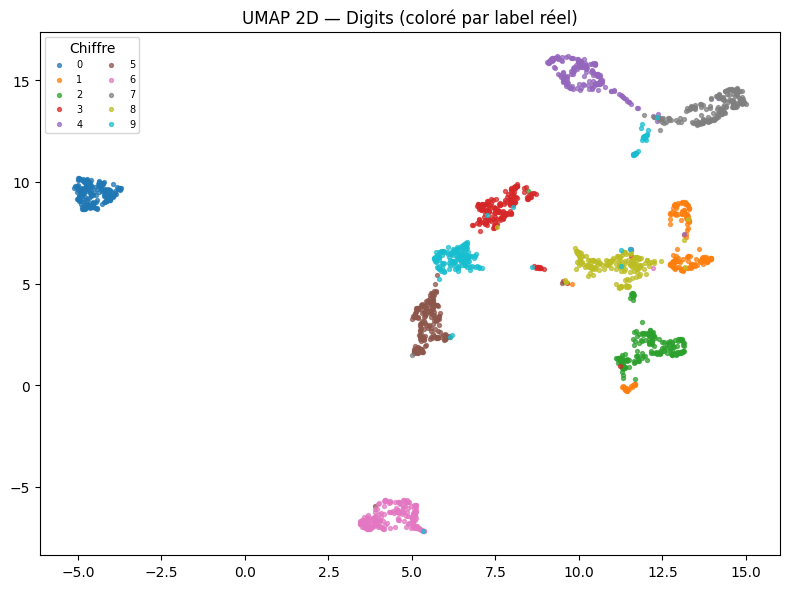

In [ ]:
try:
    import umap
    UMAP_OK = True
except ImportError:
    !pip install umap-learn --quiet
    try:
        import umap
        UMAP_OK = True
    except:
        UMAP_OK = False

if UMAP_OK:
    # UMAP sur Digits (64 dimensions)
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    X_dig_umap = reducer.fit_transform(X_dig)

    # K-Means sur la représentation UMAP
    km_umap = KMeans(n_clusters=10, init='k-means++', n_init=10, random_state=42)
    labels_umap = km_umap.fit_predict(X_dig_umap)

    eval_clustering(X_dig_umap, labels_umap, "UMAP + K-Means K=10 (Digits)")

    plt.figure(figsize=(8, 6))
    cmap10 = cm.get_cmap('tab10', 10)
    for k in range(10):
        mask = digits.target == k
        plt.scatter(X_dig_umap[mask, 0], X_dig_umap[mask, 1],
                    s=8, color=cmap10(k), label=str(k), alpha=0.7)
    plt.title("UMAP 2D — Digits (coloré par label réel)")
    plt.legend(title="Chiffre", ncol=2, fontsize=7)
    plt.tight_layout()
    plt.show()
else:
    # Fallback : PCA + K-Means
    print("UMAP non disponible — utilisation de PCA + K-Means")
    pca10 = PCA(n_components=10, random_state=42)
    X_dig_pca = pca10.fit_transform(X_dig)
    km_pca = KMeans(n_clusters=10, init='k-means++', n_init=10, random_state=42)
    labels_pca = km_pca.fit_predict(X_dig_pca)
    eval_clustering(X_dig_pca, labels_pca, "PCA + K-Means K=10 (Digits)")

---
# 📊 Comparaison globale de tous les algorithmes

Algorithme             | Clusters | Bruit | Silhouette
K-Means K=3            |        3 |     0 |     0.4599
HAC Ward K=3           |        3 |     0 |     0.4467
GMM full K=3           |        3 |     0 |     0.4751
Spectral K=3           |        3 |     0 |     0.4630
DBSCAN                 |        2 |    34 |     0.6559
OPTICS                 |        5 |   109 |     0.5524
AffinityProp           |        9 |     0 |     0.3140


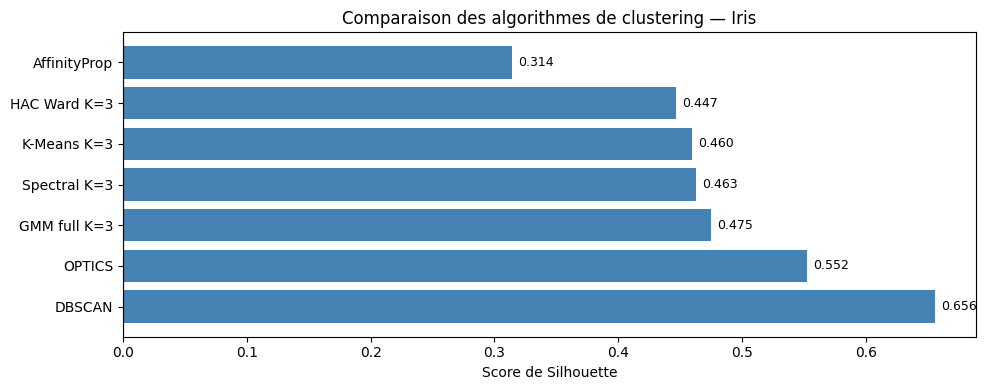

In [ ]:
from sklearn.cluster import (KMeans, DBSCAN, OPTICS,
                              AgglomerativeClustering, SpectralClustering,
                              AffinityPropagation, MeanShift, Birch)
from sklearn.mixture import GaussianMixture

algorithms = {
    "K-Means K=3":        KMeans(n_clusters=3, n_init=10, random_state=42),
    "HAC Ward K=3":       AgglomerativeClustering(n_clusters=3, linkage='ward'),
    "GMM full K=3":       GaussianMixture(n_components=3, covariance_type='full', random_state=42),
    "Spectral K=3":       SpectralClustering(n_clusters=3, affinity='rbf', random_state=42, n_jobs=-1),
    "DBSCAN":             DBSCAN(eps=0.5, min_samples=5),
    "OPTICS":             OPTICS(min_samples=5, xi=0.05),
    "AffinityProp":       AffinityPropagation(damping=0.7, random_state=42),
}

print(f"{'Algorithme':22s} | {'Clusters':>8} | {'Bruit':>5} | {'Silhouette':>10}")
print("=" * 55)
results = []
for name, algo in algorithms.items():
    if hasattr(algo, 'fit_predict'):
        lbl = algo.fit_predict(X_iris)
    else:
        algo.fit(X_iris)
        lbl = algo.predict(X_iris)
    nc  = len(set(lbl)) - (1 if -1 in lbl else 0)
    nb  = list(lbl).count(-1)
    mask = lbl != -1
    sil = silhouette_score(X_iris[mask], lbl[mask]) if nc >= 2 and mask.sum() > 1 else None
    sil_str = f"{sil:.4f}" if sil else "  N/A "
    print(f"{name:22s} | {nc:>8d} | {nb:>5d} | {sil_str:>10}")
    if sil: results.append((name, sil))

# Graphique comparatif
if results:
    names_r, sils_r = zip(*sorted(results, key=lambda x: x[1], reverse=True))
    plt.figure(figsize=(10, 4))
    bars = plt.barh(names_r, sils_r, color='steelblue')
    plt.xlabel("Score de Silhouette")
    plt.title("Comparaison des algorithmes de clustering — Iris")
    plt.axvline(0, color='black', linewidth=0.8)
    for bar, val in zip(bars, sils_r):
        plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

## 🔍 Analyse détaillée de la silhouette — K-Means

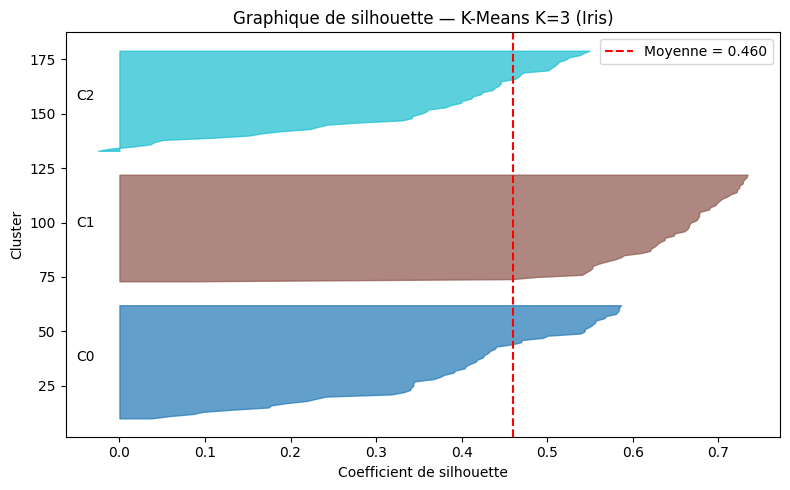

In [ ]:
from sklearn.metrics import silhouette_samples

km_sil = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_sil = km_sil.fit_predict(X_iris)
sil_vals   = silhouette_samples(X_iris, labels_sil)
avg_sil    = silhouette_score(X_iris, labels_sil)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
cmap3 = cm.get_cmap('tab10', 3)
for k in range(3):
    ith_vals = np.sort(sil_vals[labels_sil == k])
    size_k   = ith_vals.shape[0]
    y_upper  = y_lower + size_k
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals,
                      facecolor=cmap3(k), edgecolor=cmap3(k), alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_k, f"C{k}")
    y_lower  = y_upper + 10

ax.axvline(x=avg_sil, color='red', linestyle='--', label=f"Moyenne = {avg_sil:.3f}")
ax.set_title("Graphique de silhouette — K-Means K=3 (Iris)")
ax.set_xlabel("Coefficient de silhouette")
ax.set_ylabel("Cluster")
ax.legend()
plt.tight_layout()
plt.show()

---
## 🗺️ Guide de sélection de l'algorithme

In [ ]:
guide = """
╔══════════════════════════════════════════════════════════════════╗
║           GUIDE DE SÉLECTION — ALGORITHME DE CLUSTERING          ║
╠══════════════════════════════════════════════════════════════════╣
║  Données haute dimension (>50 features) ?                        ║
║  └─ Oui  → UMAP + K-Means  |  SOM                               ║
║  └─ Non  ↓                                                       ║
║                                                                  ║
║  Connais-je K (nombre de clusters) ?                             ║
║  └─ Non  → DBSCAN | HDBSCAN | OPTICS | HAC | AffinityProp        ║
║  └─ Oui  ↓                                                       ║
║                                                                  ║
║  Clusters de formes arbitraires (non-convexes) ?                 ║
║  └─ Oui  → DBSCAN | HDBSCAN | Spectral Clustering                ║
║  └─ Non  ↓                                                       ║
║                                                                  ║
║  Beaucoup de bruit / outliers ?                                   ║
║  └─ Oui  → DBSCAN | HDBSCAN | K-Medoids | K-Medians             ║
║  └─ Non  ↓                                                       ║
║                                                                  ║
║  Probabilités d'appartenance nécessaires ?                       ║
║  └─ Oui  → GMM | HDBSCAN                                         ║
║  └─ Non  ↓                                                       ║
║                                                                  ║
║  Hiérarchie des clusters nécessaire ?                            ║
║  └─ Oui  → HAC | HDBSCAN | OPTICS                                ║
║  └─ Non  → K-Means  ← solution par défaut, rapide et efficace   ║
╠══════════════════════════════════════════════════════════════════╣
║  TABLEAU COMPARATIF                                              ║
║  Algorithme      | K requis | Forme    | Outliers | Scalabilité  ║
║  K-Means         | Oui      | Convexe  | Sensible | Très haute   ║
║  K-Medoids       | Oui      | Convexe  | Robuste  | Moyenne      ║
║  DBSCAN          | Non      | Libre    | Robuste  | Haute        ║
║  HDBSCAN         | Non      | Libre    | Robuste  | Haute        ║
║  HAC             | Non*     | Libre    | Sensible | Faible       ║
║  GMM             | Oui      | Ellipse  | Sensible | Haute        ║
║  Spectral        | Oui      | Libre    | Modéré   | Faible       ║
║  AffinityProp    | Non      | Libre    | Modéré   | Faible       ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(guide)

---
## ✅ Conclusion

Il n'existe **pas d'algorithme universellement supérieur** — le choix dépend de :
- La **nature des données** (forme, dimension, bruit)
- La **connaissance a priori** (K connu ou non)
- Les **contraintes computationnelles** (taille du dataset)

**Recommandations pratiques :**
1. Commencer par une **analyse exploratoire** (PCA/UMAP)
2. Tester **plusieurs algorithmes** et comparer les scores de silhouette
3. Valider avec une **expertise métier**
4. Utiliser **K-Means** comme baseline rapide, puis affiner avec HDBSCAN ou GMM

> *Mars 2026 — A. LArhlimi | Scikit-learn · Matplotlib · Datasets : Iris, Wine, Digits*